99pctile: 10.419411230087276
5pctile: 1.632267451286314


ValueError: 'oranges' is not a valid value for cmap; supported values are 'Accent', 'Accent_r', 'Blues', 'Blues_r', 'BrBG', 'BrBG_r', 'BuGn', 'BuGn_r', 'BuPu', 'BuPu_r', 'CMRmap', 'CMRmap_r', 'Dark2', 'Dark2_r', 'GnBu', 'GnBu_r', 'Grays', 'Grays_r', 'Greens', 'Greens_r', 'Greys', 'Greys_r', 'OrRd', 'OrRd_r', 'Oranges', 'Oranges_r', 'PRGn', 'PRGn_r', 'Paired', 'Paired_r', 'Pastel1', 'Pastel1_r', 'Pastel2', 'Pastel2_r', 'PiYG', 'PiYG_r', 'PuBu', 'PuBuGn', 'PuBuGn_r', 'PuBu_r', 'PuOr', 'PuOr_r', 'PuRd', 'PuRd_r', 'Purples', 'Purples_r', 'RdBu', 'RdBu_r', 'RdGy', 'RdGy_r', 'RdPu', 'RdPu_r', 'RdYlBu', 'RdYlBu_r', 'RdYlGn', 'RdYlGn_r', 'Reds', 'Reds_r', 'Set1', 'Set1_r', 'Set2', 'Set2_r', 'Set3', 'Set3_r', 'Spectral', 'Spectral_r', 'Wistia', 'Wistia_r', 'YlGn', 'YlGnBu', 'YlGnBu_r', 'YlGn_r', 'YlOrBr', 'YlOrBr_r', 'YlOrRd', 'YlOrRd_r', 'afmhot', 'afmhot_r', 'autumn', 'autumn_r', 'berlin', 'berlin_r', 'binary', 'binary_r', 'bone', 'bone_r', 'brg', 'brg_r', 'bwr', 'bwr_r', 'cividis', 'cividis_

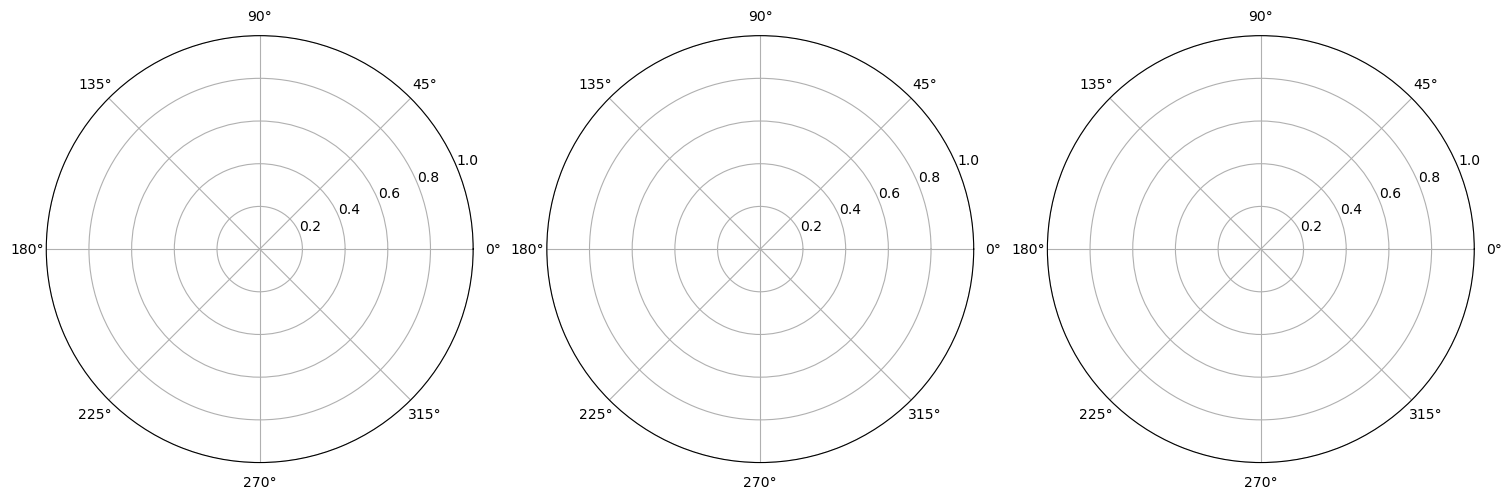

In [12]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm


# ============================================================
# USER SETTINGS
# ============================================================
out_dir = "F:/crs/proj/2025_NOPP_comparison/helene_contour_all3/"

DIR_CONVENTION = "to"   # use "to" or "from"
DEPTH_M = 30.0          # replace with pointwise depth if available
REF_MODEL = "cw"        # "hw", "ad", or "cw"


# ============================================================
# LOAD DATA
# ============================================================
ds_hw = xr.open_dataset(out_dir + "hurrywave_aligned.nc")
ds_ad = xr.open_dataset(out_dir + "adcirc_aligned.nc")
ds_cw = xr.open_dataset(out_dir + "coawst_aligned.nc")


# ============================================================
# DIRECTION / VECTOR HELPERS
# Geographic convention:
# azimuth (deg clockwise from north)
# x = east, y = north
# ============================================================
def az_to_xy(az_deg):
    az_rad = np.deg2rad(az_deg)
    x = np.sin(az_rad)   # east
    y = np.cos(az_rad)   # north
    return x, y


def xy_to_az(x, y):
    return (np.degrees(np.arctan2(x, y)) + 360.0) % 360.0


def convert_dirs(dir_deg, dir_convention="to"):
    """
    Convert dataset directions to TOWARD azimuths.

    Parameters
    ----------
    dir_deg : array-like
        Geographic azimuths (deg clockwise from north).
    dir_convention : {"to", "from"}
        Convention used in the dataset.
    """
    d = np.asarray(dir_deg, float) % 360.0

    if dir_convention.lower() == "to":
        return d
    elif dir_convention.lower() == "from":
        return (d + 180.0) % 360.0
    else:
        raise ValueError("dir_convention must be 'to' or 'from'")


def circular_bin_edges(dir_deg):
    """
    Build monotonic circular bin edges from direction bin centers.

    Parameters
    ----------
    dir_deg : array-like
        Direction bin centers (deg), any order.

    Returns
    -------
    dc : ndarray
        Sorted direction centers on [0, 360).
    edges : ndarray
        Direction edges, length nd+1, monotonic.
        Final edge may exceed 360 to close the circle cleanly.
    srt : ndarray
        Sort index such that dc = dir_deg[srt] (mod 360).
    """
    d = np.asarray(dir_deg, float) % 360.0
    srt = np.argsort(d)
    dc = d[srt]

    # Circular extension
    dc_ext = np.r_[dc, dc[0] + 360.0]
    dd = np.diff(dc_ext)

    edges = np.empty(dc.size + 1, dtype=float)
    edges[1:-1] = 0.5 * (dc[:-1] + dc[1:])
    edges[0] = dc[0] - 0.5 * dd[0]
    edges[-1] = dc[-1] + 0.5 * dd[-1]

    # Make monotonic and non-negative for polar plotting
    while edges[0] < 0:
        edges[0] += 360.0
        edges[-1] += 360.0

    return dc, edges, srt


def radial_bin_edges_from_centers(r):
    """
    Build radial cell edges from strictly increasing radial centers.
    """
    r = np.asarray(r, float)
    if np.any(np.diff(r) <= 0):
        raise ValueError("Radial centers must be strictly increasing")

    edges = np.empty(r.size + 1, dtype=float)
    edges[1:-1] = 0.5 * (r[:-1] + r[1:])
    edges[0] = r[0] - 0.5 * (r[1] - r[0])
    edges[-1] = r[-1] + 0.5 * (r[-1] - r[-2])

    edges[0] = max(edges[0], 0.0)
    return edges


# ============================================================
# GROUP VELOCITY
# ============================================================
def calc_cg_intermediate(freq, depth, g=9.81, niter=4):
    """
    Calculate group velocity (m/s) in intermediate water.

    Parameters
    ----------
    freq : array-like
        Frequency (Hz)
    depth : float
        Water depth (m)
    """
    f = np.atleast_1d(freq).astype(float)
    h = float(depth)

    omega = 2.0 * np.pi * f
    x = omega**2 * h / g

    # Initial guess for kh
    y = np.where(x < 1.0, np.sqrt(x), x)

    for _ in range(niter):
        t = np.tanh(y)
        y = y - (y * t - x) / (t + y * (1.0 - t**2))

    kh = y
    k = kh / h
    cp = np.sqrt((g / k) * np.tanh(kh))
    n = 0.5 * (1.0 + (2.0 * kh) / np.sinh(2.0 * kh))
    cg = n * cp

    return cg


# ============================================================
# FLUX CALCULATION FROM ONE 2D SPECTRUM
# ============================================================
def calc_fluxes_from_spec(
    spec,
    freq,
    dir_deg,
    nx,
    ny,
    depth=15.0,
    dir_convention="to",
    rho=1025.0,
    g=9.81,
):
    """
    Calculate bulk and shoreward wave-energy fluxes from one 2D spectrum.

    Parameters
    ----------
    spec : ndarray
        2D directional spectrum, shape (nf, nd), units (m^2/Hz/rad)
    freq : ndarray
        Frequency array, shape (nf,), units (Hz)
    dir_deg : ndarray
        Direction bin centers, shape (nd,), geographic azimuth
    nx, ny : float
        Shoreward unit normal components
    depth : float
        Water depth (m)
    dir_convention : {"to", "from"}
        Convention used in dir_deg

    Returns
    -------
    dict containing:
        Fx, Fy           : net bulk flux vector components (W/m)
        Fbulk            : bulk flux magnitude (W/m)
        Fdir             : bulk flux direction (deg, toward)
        Fshore_dot       : shoreward flux by dot product (W/m)
        Fshore_hemi      : shoreward hemispheric flux (W/m)
    """
    S = np.asarray(spec, float)
    f = np.asarray(freq, float)

    # Convert directions to TOWARD azimuths
    d_toward = convert_dirs(dir_deg, dir_convention=dir_convention)

    # Sort direction bins and spectrum consistently
    d_sorted, d_edges, srt = circular_bin_edges(d_toward)
    S = S[:, srt]

    # Directional unit vectors
    sx, sy = az_to_xy(d_sorted)

    # Direction bin widths (radians)
    dtheta = np.deg2rad(np.diff(d_edges))

    # Group velocity
    cg = calc_cg_intermediate(f, depth)

    # Flux density factor
    fac = rho * g * cg[:, None] * S

    # Vector components integrated over direction, then frequency
    Fx_f = np.sum(fac * sx[None, :] * dtheta[None, :], axis=1)
    Fy_f = np.sum(fac * sy[None, :] * dtheta[None, :], axis=1)

    Fx = np.trapezoid(Fx_f, f)
    Fy = np.trapezoid(Fy_f, f)

    Fbulk = np.hypot(Fx, Fy)
    Fdir = xy_to_az(Fx, Fy)

    # Dot-product shoreward flux
    Fshore_dot = nx * Fx + ny * Fy

    # Hemispheric shoreward-only flux
    ndotd = nx * sx + ny * sy
    hemi_f = np.sum(fac * np.maximum(0.0, ndotd)[None, :] * dtheta[None, :], axis=1)
    Fshore_hemi = np.trapezoid(hemi_f, f)

    return {
        "Fx": Fx,
        "Fy": Fy,
        "Fbulk": Fbulk,
        "Fdir": Fdir,
        "Fshore_dot": Fshore_dot,
        "Fshore_hemi": Fshore_hemi,
        "dir_toward_sorted": d_sorted,
        "dir_edges_toward": d_edges,
    }


# ============================================================
# COMPUTE SHOREWARD FLUX FIELD FOR ALL TIMES / POINTS
# ============================================================
def compute_fshore_field(ds, depth=30.0, dir_convention="to"):
    """
    Compute dot-product shoreward energy flux for all (time, point).
    """
    nt = ds.sizes["time"]
    npnt = ds.sizes["point"]

    out = np.full((nt, npnt), np.nan, dtype=float)

    freq = ds["freq"].values
    dir_deg = ds["dir"].values
    nx = ds["normal_x"].values
    ny = ds["normal_y"].values

    # Normalize normals
    nn = np.hypot(nx, ny)
    nx = nx / nn
    ny = ny / nn

    for it in range(nt):
        for ip in range(npnt):
            S = ds["spec"].isel(time=it, point=ip).values
            F = calc_fluxes_from_spec(
                S, freq, dir_deg, nx[ip], ny[ip],
                depth=depth,
                dir_convention=dir_convention
            )
            out[it, ip] = F["Fshore_dot"]

    return xr.DataArray(
        out,
        coords={"time": ds["time"], "point": ds["point"]},
        dims=("time", "point"),
        name="fshore_dot",
        attrs={"units": "W/m"}
    )


def choose_peak_location(ds_ref, depth=30.0, dir_convention="to"):
    """
    Find (time, point) of maximum dot-product shoreward flux.
    """
    fshore = compute_fshore_field(ds_ref, depth=depth, dir_convention=dir_convention)
    arr = fshore.values
    it, ip = np.unravel_index(np.nanargmax(arr), arr.shape)
    return int(it), int(ip), fshore


def nearest_time_index(ds, target_time):
    """
    Find nearest time index in ds to target_time.
    """
    t = ds["time"].values
    return int(np.argmin(np.abs(t - np.datetime64(target_time))))


# ============================================================
# POLAR SPECTRUM PLOT
# ============================================================
def plot_spec_polar(
    ax,
    spec,
    freq,
    dir_deg,
    title="",
    dir_convention="to",
    normal_az=None,
    bulk_az=None,
    vmin=1e-3,
    vmax=1,
    cmap="inferno",
    r_as_period=True,
):
    """
    Plot 2D directional spectrum on polar axes using proper cell edges.

    Parameters
    ----------
    spec : ndarray
        Shape (nf, nd)
    freq : ndarray
        Shape (nf,)
    dir_deg : ndarray
        Shape (nd,)
    dir_convention : {"to", "from"}
    normal_az : float or None
        Shoreward normal azimuth (deg)
    bulk_az : float or None
        Bulk flux direction azimuth (deg)
    r_as_period : bool
        If True, radius = period (s); else radius = frequency (Hz)
    """
    S = np.asarray(spec, float)
    f = np.asarray(freq, float)

    # Convert to TOWARD azimuths for display
    d_toward = convert_dirs(dir_deg, dir_convention=dir_convention)

    # Sort directions and reorder spectrum
    d_sorted, d_edges, srt = circular_bin_edges(d_toward)
    S = S[:, srt]

    # Radial coordinate
    if r_as_period:
        r_cent = 1.0 / f
        rsrt = np.argsort(r_cent)
        r_cent = r_cent[rsrt]
        S = S[rsrt, :]
    else:
        r_cent = f
        rsrt = np.argsort(r_cent)
        r_cent = r_cent[rsrt]
        S = S[rsrt, :]

    r_edges = radial_bin_edges_from_centers(r_cent)

    # Edge grids for pcolormesh
    TH, RR = np.meshgrid(np.deg2rad(d_edges), r_edges)

    zpos = S[S > 0]
    print(f"99pctile: {np.nanpercentile(zpos, 99)}")
    print(f"5pctile: {np.nanpercentile(zpos, 95)}")

    # if vmin is None:
    #     vmin = np.nanpercentile(zpos, 5) if zpos.size else 1e-8
    # if vmax is None:
    #     vmax = np.nanpercentile(zpos, 99) if zpos.size else 1.0

    Z = np.maximum(S, vmin)

    pcm = ax.pcolormesh(
        TH, RR, Z,
        shading="flat",
        cmap=cmap,
        norm=LogNorm(vmin=vmin, vmax=vmax)
    )

    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_title(title, fontsize=10)

    rmax = r_edges[-1]

    # Shoreward normal and hemisphere bounds
    if normal_az is not None:
        thn = np.deg2rad(normal_az % 360.0)
        ax.plot([thn, thn], [0, rmax], "--", lw=2)

        th1 = np.deg2rad((normal_az - 90.0) % 360.0)
        th2 = np.deg2rad((normal_az + 90.0) % 360.0)
        ax.plot([th1, th1], [0, rmax], ":", lw=1.2)
        ax.plot([th2, th2], [0, rmax], ":", lw=1.2)

    # Bulk flux direction
    if bulk_az is not None:
        thb = np.deg2rad(bulk_az % 360.0)
        ax.plot([thb, thb], [0, rmax], "-", lw=2)

    return pcm


# ============================================================
# THREE-MODEL COMPARISON PLOT
# ============================================================
def compare_three_spectra(
    ds_hw,
    ds_ad,
    ds_cw,
    depth=15.0,
    dir_convention="to",
    ref_model="cw",
    it=None,
    ip=None,
    vmin=1e-3,
    vmax=1,
    cmap="inferno",
):
    """
    Compare polar spectra from HurryWave, ADCIRC, and COAWST/WW3
    at one selected point and time.

    Selection defaults to the global maximum dot-product shoreward
    flux in the reference model.
    """
    ref_lookup = {"hw": ds_hw, "ad": ds_ad, "cw": ds_cw}
    ds_ref = ref_lookup[ref_model]

    if (it is None) or (ip is None):
        it, ip, fshore_ref = choose_peak_location(
            ds_ref, depth=depth, dir_convention=dir_convention
        )
    else:
        fshore_ref = compute_fshore_field(
            ds_ref, depth=depth, dir_convention=dir_convention
        )

    tref = ds_ref["time"].values[it]

    ithw = nearest_time_index(ds_hw, tref)
    itad = nearest_time_index(ds_ad, tref)
    itcw = nearest_time_index(ds_cw, tref)

    Shw = ds_hw["spec"].isel(time=ithw, point=ip).values
    Sad = ds_ad["spec"].isel(time=itad, point=ip).values
    Scw = ds_cw["spec"].isel(time=itcw, point=ip).values

    # Use reference-model normal at selected point
    nx = float(ds_ref["normal_x"].isel(point=ip).values)
    ny = float(ds_ref["normal_y"].isel(point=ip).values)
    nn = np.hypot(nx, ny)
    nx /= nn
    ny /= nn
    normal_az = xy_to_az(nx, ny)

    Fhw = calc_fluxes_from_spec(
        Shw, ds_hw["freq"].values, ds_hw["dir"].values,
        nx, ny, depth=depth, dir_convention=dir_convention
    )
    Fad = calc_fluxes_from_spec(
        Sad, ds_ad["freq"].values, ds_ad["dir"].values,
        nx, ny, depth=depth, dir_convention=dir_convention
    )
    Fcw = calc_fluxes_from_spec(
        Scw, ds_cw["freq"].values, ds_cw["dir"].values,
        nx, ny, depth=depth, dir_convention=dir_convention
    )

    # Common color scale
    allvals = np.concatenate([Shw.ravel(), Sad.ravel(), Scw.ravel()])
    pos = allvals[allvals > 0]
    # vmin = np.nanpercentile(pos, 5) if pos.size else 1e-8
    # vmax = np.nanpercentile(pos, 99) if pos.size else 1.0
    
    fig, axs = plt.subplots(
        1, 3,
        figsize=(15, 5),
        subplot_kw={"projection": "polar"},
        constrained_layout=True
    )

    pcm = plot_spec_polar(
        axs[0], Shw, ds_hw["freq"].values, ds_hw["dir"].values,
        title=(f"HurryWave\n"
               f"dot = {Fhw['Fshore_dot']:.0f} (W/m), "
               f"hemi = {Fhw['Fshore_hemi']:.0f} (W/m)"),
        dir_convention=dir_convention,
        normal_az=normal_az,
        bulk_az=Fhw["Fdir"],
        vmin=vmin, vmax=vmax, cmap=cmap
    )

    plot_spec_polar(
        axs[1], Sad, ds_ad["freq"].values, ds_ad["dir"].values,
        title=(f"ADCIRC\n"
               f"dot = {Fad['Fshore_dot']:.0f} (W/m), "
               f"hemi = {Fad['Fshore_hemi']:.0f} (W/m)"),
        dir_convention=dir_convention,
        normal_az=normal_az,
        bulk_az=Fad["Fdir"],
        vmin=vmin, vmax=vmax, cmap=cmap
    )

    plot_spec_polar(
        axs[2], Scw, ds_cw["freq"].values, ds_cw["dir"].values,
        title=(f"COAWST/WW3\n"
               f"dot = {Fcw['Fshore_dot']:.0f} (W/m), "
               f"hemi = {Fcw['Fshore_hemi']:.0f} (W/m)"),
        dir_convention=dir_convention,
        normal_az=normal_az,
        bulk_az=Fcw["Fdir"],
        vmin=vmin, vmax=vmax
    )

    cbar = fig.colorbar(pcm, ax=axs, shrink=0.82, pad=0.08)
    cbar.set_label(r"Spec (m$^2$ Hz$^{-1}$ rad$^{-1}$)")

    src_txt = (
        "Wave sources: HurryWave aligned contour spectra; ADCIRC aligned contour spectra; "
        "COAWST/WW3 aligned contour spectra. "
        "Spectra stored as spec(time, point, freq, dir), units (m^2/Hz/rad). "
        f"Direction convention treated here as '{dir_convention}'."
    )

    fig.suptitle(
        f"Aligned contour spectra at point {ip}, reference time {np.datetime_as_string(tref, unit='m')}\n"
        f"Normal azimuth = {normal_az:.1f} deg ; depth = {depth:.1f} (m)",
        y=1.05
    )
    fig.text(0.5, 0.01, src_txt, ha="center", va="bottom", fontsize=9)

    return fig, axs, {
        "point": ip,
        "time_ref": tref,
        "normal_az": normal_az,
        "HurryWave": Fhw,
        "ADCIRC/SWAN": Fad,
        "COAWST/WW3": Fcw,
        "fshore_ref": fshore_ref,
    }


# ============================================================
# OPTIONAL QUICK CHECKS
# ============================================================
def print_direction_check(ds):
    print("dir values:")
    print(ds["dir"].values)
    print("\nsorted spacing (deg):")
    print(np.diff(np.sort(ds["dir"].values % 360.0)))


def print_flux_summary(out):
    for name in ["HurryWave", "ADCIRC/SWAN", "COAWST/WW3"]:
        Fd = out[name]["Fshore_dot"]
        Fh = out[name]["Fshore_hemi"]
        ratio = Fh / Fd if Fd != 0 else np.nan
        print(
            f"{name:12s}  "
            f"dot = {Fd:10.2f} (W/m)  "
            f"hemi = {Fh:10.2f} (W/m)  "
            f"hemi/dot = {ratio:8.3f}"
        )


# ============================================================
# RUN
# ============================================================
fig, axs, out = compare_three_spectra(
    ds_hw,
    ds_ad,
    ds_cw,
    depth=DEPTH_M,
    dir_convention=DIR_CONVENTION,
    ref_model=REF_MODEL,
    vmin=1e-3,
    vmax=10,
    cmap="oranges",
)

plt.show()

print_flux_summary(out)